In this notebook we will cover standard approaches to estimate expectation values of Pauli observables and provide an estimate of the statistical error.

**NOTE**: the BONUS section and exercise at the end cover more advanced material which is not required to follow the classes at the school but could be useful if you want to learn more

### Packages

Before using this notebook make sure you install in your Python environment the following packages

- qiskit (versions 2.1.2 and 2.3.0 have been tested and work fine)
- qiskit-aer (version 0.17.2)
- pylatexenc

If you have trouble installing the packages on your machine, you can try to run this on [Colab](https://colab.research.google.com). In this case you will need to run the following cell to proceed with the installation

In [1]:
%pip install uv --quiet
!uv pip install --quiet \
    "qiskit==2.1.2" \
    "qiskit-aer==0.17.2"\
    pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 41.3 MB/s eta 0:00:00


### Reference calculation using numpy and state-vector simulator

We will try to prepare the following initial state

$$\rvert\Psi(\theta)\rangle = \cos(\theta)\rvert 01\rangle+\sin(\theta)\rvert10\rangle$$

and then estimate the some Pauli expectation values on it.

In [2]:
# let's code the ideal circuit in numpy first
import numpy as np

# we start defining all the Pauli observables
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
# and now all possible two qubit observables
## NOTE: qiskit uses an ordering that goes left to right, we will do the same here
X_1 = np.kron(X,I); Y_1 = np.kron(Y,I); Z_1 = np.kron(Z,I)
X_0 = np.kron(I,X); Y_0 = np.kron(I,Y); Z_0 = np.kron(I,Z)
X_0X_1 = np.kron(X,X); Y_0X_1 = np.kron(X,Y); Z_0X_1 = np.kron(X,Z)
X_0Y_1 = np.kron(Y,X); Y_0Y_1 = np.kron(Y,Y); Z_0Y_1 = np.kron(Y,Z)
X_0Z_1 = np.kron(Z,X); Y_0Z_1 = np.kron(Z,Y); Z_0Z_1 = np.kron(Z,Z)

In [3]:
# these are the computational states
zero_state=np.array([1,0])
one_state=np.array([0,1])
# and with Pauli X we can map one into the other, for instance
print(X@zero_state)

[0.+0.j 1.+0.j]


In [4]:
theta=0.5
# note the ordering convention to comply with the one in qiskit
state_01 = np.kron(one_state,zero_state)
state_10 = np.kron(zero_state,one_state)
# this is our target state
psi_theta = np.cos(theta)*state_01+np.sin(theta)*state_10

In [5]:
## now we print all the possible Pauli expectation values on this state
print(f"<X_0>: {np.vdot(psi_theta,X_0@psi_theta)}\t<X_1>: {np.vdot(psi_theta,X_1@psi_theta)}")
print(f"<Y_0>: {np.vdot(psi_theta,Y_0@psi_theta)}\t<Y_1>: {np.vdot(psi_theta,Y_1@psi_theta)}")
print(f"<Z_0>: {np.vdot(psi_theta,Z_0@psi_theta)}\t<Z_1>: {np.vdot(psi_theta,Z_1@psi_theta)}")
print(f"<X_0X_1>: {np.vdot(psi_theta,X_0X_1@psi_theta)}\t \
        <X_0Y_1>: {np.vdot(psi_theta,X_0Y_1@psi_theta)}\t \
        <X_0Z_1>: {np.vdot(psi_theta,X_0Z_1@psi_theta)}")
print(f"<Y_0X_1>: {np.vdot(psi_theta,Y_0X_1@psi_theta)}\t \
        <Y_0Y_1>: {np.vdot(psi_theta,Y_0Y_1@psi_theta)}\t \
        <Y_0Z_1>: {np.vdot(psi_theta,Y_0Z_1@psi_theta)}")
print(f"<Z_0X_1>: {np.vdot(psi_theta,Z_0X_1@psi_theta)}\t \
        <Z_0Y_1>: {np.vdot(psi_theta,Z_0Y_1@psi_theta)}\t \
        <Z_0Z_1>: {np.vdot(psi_theta,Z_0Z_1@psi_theta)}")

<X_0>: 0j	<X_1>: 0j
<Y_0>: 0j	<Y_1>: 0j
<Z_0>: (0.5403023058681398+0j)	<Z_1>: (-0.5403023058681398+0j)
<X_0X_1>: (0.8414709848078965+0j)	         <X_0Y_1>: 0j	         <X_0Z_1>: 0j
<Y_0X_1>: 0j	         <Y_0Y_1>: (0.8414709848078965+0j)	         <Y_0Z_1>: 0j
<Z_0X_1>: 0j	         <Z_0Y_1>: 0j	         <Z_0Z_1>: (-1+0j)


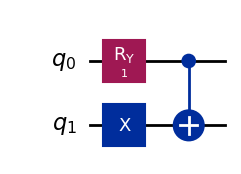

In [6]:
from qiskit import transpile
from qiskit import QuantumCircuit

circuitA = QuantumCircuit(2)
## note the factor of 2 needed to comply with qiskit conventions
circuitA.ry(2*theta,0)
circuitA.x(1)
circuitA.cx(0, 1)

circuitA.draw('mpl')

In order to extract the ideal state-vector we import qiskit-aer and make a copy of the circuit as follows

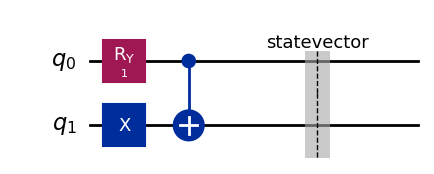

In [7]:
from qiskit_aer import AerSimulator

circuitA_sv = circuitA.copy()
circuitA_sv.save_statevector()
circuitA_sv.draw('mpl')

In [8]:
## run simulator and extract resulting vector
sim_statevector = AerSimulator(method='statevector')
job_sv = sim_statevector.run(circuitA_sv)
result_sv = job_sv.result()
outputstate_sv = result_sv.get_statevector(circuitA_sv, decimals=8)
## convert output Statevector objoect into a numpy array
psi_sv = np.array(outputstate_sv.data.tolist())
print(psi_sv)

[0.        +0.j 0.47942554+0.j 0.87758256+0.j 0.        +0.j]


Now we can evaluate the expectation values of the state-vector

In [9]:
print(f"<X_0>: {np.vdot(psi_sv,X_0@psi_sv)}\t<X_1>: {np.vdot(psi_sv,X_1@psi_sv)}")
print(f"<Y_0>: {np.vdot(psi_sv,Y_0@psi_sv)}\t<Y_1>: {np.vdot(psi_sv,Y_1@psi_sv)}")
print(f"<Z_0>: {np.vdot(psi_sv,Z_0@psi_sv)}\t<Z_1>: {np.vdot(psi_sv,Z_1@psi_sv)}")
print(f"<X_0X_1>: {np.vdot(psi_sv,X_0X_1@psi_sv)}\t \
        <X_0Y_1>: {np.vdot(psi_sv,X_0Y_1@psi_sv)}\t \
        <X_0Z_1>: {np.vdot(psi_sv,X_0Z_1@psi_sv)}")
print(f"<Y_0X_1>: {np.vdot(psi_sv,Y_0X_1@psi_sv)}\t \
        <Y_0Y_1>: {np.vdot(psi_sv,Y_0Y_1@psi_sv)}\t \
        <Y_0Z_1>: {np.vdot(psi_sv,Y_0Z_1@psi_sv)}")
print(f"<Z_0X_1>: {np.vdot(psi_sv,Z_0X_1@psi_sv)}\t \
        <Z_0Y_1>: {np.vdot(psi_sv,Z_0Y_1@psi_sv)}\t \
        <Z_0Z_1>: {np.vdot(psi_sv,Z_0Z_1@psi_sv)}")

<X_0>: 0j	<X_1>: 0j
<Y_0>: 0j	<Y_1>: 0j
<Z_0>: (0.540302301211862+0j)	<Z_1>: (-0.540302301211862+0j)
<X_0X_1>: (0.8414709854451647+0j)	         <X_0Y_1>: 0j	         <X_0Z_1>: 0j
<Y_0X_1>: 0j	         <Y_0Y_1>: (0.8414709854451647+0j)	         <Y_0Z_1>: 0j
<Z_0X_1>: 0j	         <Z_0Y_1>: 0j	         <Z_0Z_1>: (-0.9999999980204453+0j)


Within numerical precision the two calculations should match.

### Inizialize a backend with the specified connectivity

Here we will generate a local backend with a connectivity similar to to one of Lagrange

In [10]:
from qiskit.providers.fake_provider import GenericBackendV2
# Generate a 5-qubit simulated backend
fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=[(0, 2), (1, 2), (2, 3), (2, 4)], ## this is the same coupling map as Lagrange
    basis_gates=["id", "rz", "sx", "x", "cz"]
)

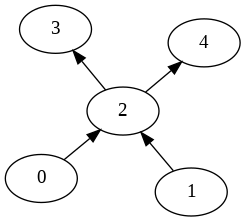

In [11]:
## we can plot the coupling map directing using the 'draw' method
fake_lagrange_backend.coupling_map.draw()

# Running a sampler simulation

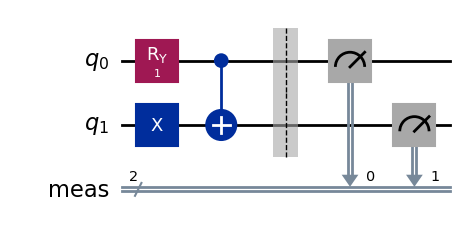

In [12]:
## let's now add measurements at the end of the circuit
circuitA_measZ = circuitA.copy()
circuitA_measZ.measure_all()
circuitA_measZ.draw('mpl')

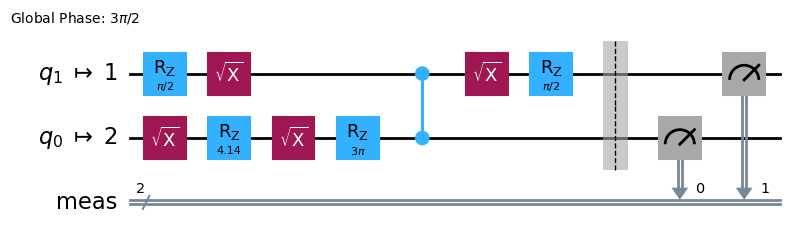

In [13]:
from qiskit import transpile
transpiled_circuitA_measZ = transpile(circuitA_measZ, backend=fake_lagrange_backend,optimization_level=2)
transpiled_circuitA_measZ.draw('mpl')

We can generate counts directly from the state-vector simulator initialized above

In [14]:
## here we fix the random seed to a fixed random number for reproducibility
sample_job = sim_statevector.run([transpiled_circuitA_measZ],shots=1024,seed_simulator=21)
counts_circuitA_measZ = sample_job.result().get_counts()

And these are the resulting counts

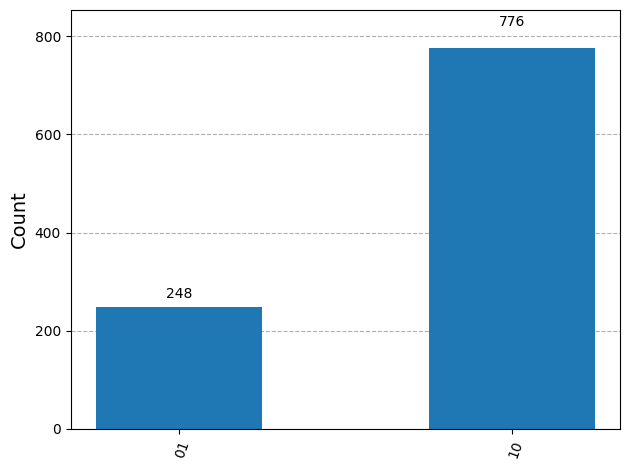

In [15]:
from qiskit.visualization import plot_histogram
plot_histogram(counts_circuitA_measZ)

We now need to convert a specific bit-string that we measure in the corresponding eigenvalue (remember, we can only measure diagonal operators). A straightforward way to do this is to implement the map explicitly like

In [16]:
counts_to_Z0 = {
    '00': 1.0,
    '01': -1.0,
    '10': 1.0,
    '11': -1.0
}

At this point we can estimate the empirical expectation value

In [17]:
average_Z0 = 0.0
tot_counts = 0
for cc in counts_circuitA_measZ:
    ## for every bit-string we measure we compute the corresponding value
    value = counts_to_Z0[cc]
    ## and accumulate the result by multiplying the number of counts
    average_Z0 += counts_circuitA_measZ[cc]*value
    ## together with the cumulative number of counts
    tot_counts += counts_circuitA_measZ[cc]
## we finish by dividing by the total number of counts
average_Z0 /= tot_counts
print(f"<Z_0> = {average_Z0}\t [ideal was: {np.vdot(psi_sv,Z_0@psi_sv)}]")

<Z_0> = 0.515625	 [ideal was: (0.540302301211862+0j)]


This method is clearly way too expensive on large systems since, if we perform a simulation on $n$ qubits, the number of elements in the dictionary will be $2^n$. A better strategy is to compute directly the eigenvalue from the bitstring. For the $Z_0$ operator used above this will look like

$$\lambda\left(Z_0,bits\right) = (-1)^{bits[0]}$$

where `bits` contain the bits in the measured bit-string so that `bits[0]` is the bit corresponding to qubit $0$.

**NOTE**: we need to pay attention to `qiskit` ordering convention, the bit corresponding to qubit $0$ will be the last one in the bit-string.

The advantage now is that, for an arbitrary product of $Z$ operators the corresponding eigenvalue can be computed on-the-fly using a bit sum

$$\lambda\left(\prod_{k=0}^MZ_{q_k},bits\right) = (-1)^{\sum_{k=0}^Mbits[q_k]}$$

    
A possible way to implement this is to store the $M$ qubit indices for a specific operator. For instance

In [18]:
bits_for_Z_0 = [0]
average_Z0 = 0.0
tot_counts = 0
for cc in counts_circuitA_measZ:
    ## convert the measured bit-string into a list of numerical values
    int_bit_string = [int(bb) for bb in cc]
    ## compute the sum of bits (note the ordering convention)
    num_qubits = len(int_bit_string)
    exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_Z_0])
    ## convert this into the corresponding value
    value = (-1)**exp_sum
    ## and accumulate the result by multiplying the number of counts
    average_Z0 += counts_circuitA_measZ[cc]*value
    ## together with the cumulative number of counts
    tot_counts += counts_circuitA_measZ[cc]
## we finish by dividing by the total number of counts
average_Z0 /= tot_counts
print(f"<Z_0> = {average_Z0}\t [ideal was: {np.vdot(psi_sv,Z_0@psi_sv)}]")

<Z_0> = 0.515625	 [ideal was: (0.540302301211862+0j)]


Since we will need to perform the same calculation for multiple Pauli observables it might be better to define a function to help us out

In [19]:
def exp_from_counts(input_counts, bits_for_observable):
    average_obs = 0.0
    tot_counts = 0
    for cc in input_counts:
        ## convert the measured bit-string into a list of numerical values
        int_bit_string = [int(bb) for bb in cc]
        ## compute the sum of bits (note the ordering convention)
        num_qubits = len(int_bit_string)
        exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_observable])
        ## convert this into the corresponding value
        value = (-1)**exp_sum
        ## and accumulate the result by multiplying the number of counts
        average_obs += input_counts[cc]*value
        ## together with the cumulative number of counts
        tot_counts += input_counts[cc]
    ## we finish by dividing by the total number of counts
    average_obs /= tot_counts

    return average_obs

Let's now see if we got the correct expectation values for diagonal operators

In [20]:
print(f"<Z_0> = {exp_from_counts(counts_circuitA_measZ,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0@psi_sv))}]")
print(f"<Z_1> = {exp_from_counts(counts_circuitA_measZ,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_1@psi_sv))}]")
print(f"<Z_0Z_1> = {exp_from_counts(counts_circuitA_measZ,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0Z_1@psi_sv))}]")

<Z_0> = 0.515625	 [ideal was: 0.540302301211862]
<Z_1> = -0.515625	 [ideal was: -0.540302301211862]
<Z_0Z_1> = -1.0	 [ideal was: -0.9999999980204453]


### Measuring off diagonal operators

If we want to measure off-diagonal operators we need to perform a change of basis before measurement

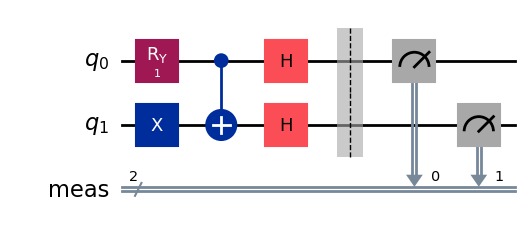

In [21]:
## let's now add measurements at the end of the circuit
circuitA_measX = circuitA.copy()
## change from X basis to Z basis with Hadamards
circuitA_measX.h([0,1])
circuitA_measX.measure_all()
circuitA_measX.draw('mpl')

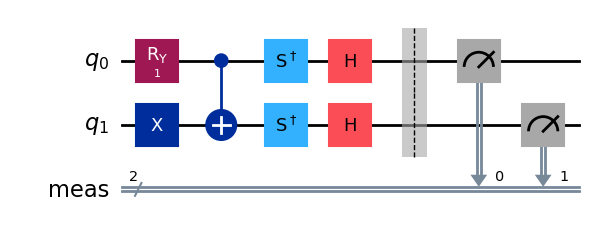

In [22]:
## let's now add measurements at the end of the circuit
circuitA_measY = circuitA.copy()
## change from Y basis to Z basis with S^\dagger and Hadamards
circuitA_measY.sdg([0,1])
circuitA_measY.h([0,1])
circuitA_measY.measure_all()
circuitA_measY.draw('mpl')

Instead of performing a single simulation for each circuit we can run multiple circuits at the same time. For instance

In [23]:
## we first make a list of the circuits we want
circuit_list = [circuitA_measX,circuitA_measY,circuitA_measZ]
## we then transpile them
transpiled_circuitA_measXYZ = []
for circ in circuit_list:
    transpiled_circuitA_measXYZ.append(transpile(circ, backend=fake_lagrange_backend,optimization_level=2))
## now we can run them in a single job
## here we fix the random seed to a fixed random number for reproducibility
sample_job = sim_statevector.run(transpiled_circuitA_measXYZ,shots=1024,seed_simulator=21)

In [24]:
## we now have a list of counts from running the job
sample_job.result().get_counts()

[{'01': 42, '11': 491, '00': 443, '10': 48},
 {'01': 35, '10': 36, '00': 451, '11': 502},
 {'01': 235, '10': 789}]

In [25]:
xcounts = sample_job.result().get_counts()[0]
print(f"<X_0> = {exp_from_counts(xcounts,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,X_0@psi_sv))}]")
print(f"<X_1> = {exp_from_counts(xcounts,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,X_1@psi_sv))}]")
print(f"<X_0X_1> = {exp_from_counts(xcounts,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,X_0X_1@psi_sv))}]")

<X_0> = -0.041015625	 [ideal was: 0.0]
<X_1> = -0.052734375	 [ideal was: 0.0]
<X_0X_1> = 0.82421875	 [ideal was: 0.8414709854451647]


In [26]:
ycounts = sample_job.result().get_counts()[1]
print(f"<Y_0> = {exp_from_counts(ycounts,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,Y_0@psi_sv))}]")
print(f"<Y_1> = {exp_from_counts(ycounts,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,Y_1@psi_sv))}]")
print(f"<Y_0Y_1> = {exp_from_counts(ycounts,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,Y_0Y_1@psi_sv))}]")

<Y_0> = -0.048828125	 [ideal was: 0.0]
<Y_1> = -0.05078125	 [ideal was: 0.0]
<Y_0Y_1> = 0.861328125	 [ideal was: 0.8414709854451647]


In [27]:
zcounts = sample_job.result().get_counts()[2]
print(f"<Z_0> = {exp_from_counts(zcounts,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0@psi_sv))}]")
print(f"<Z_1> = {exp_from_counts(zcounts,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_1@psi_sv))}]")
print(f"<Z_0Z_1> = {exp_from_counts(zcounts,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0Z_1@psi_sv))}]")

<Z_0> = 0.541015625	 [ideal was: 0.540302301211862]
<Z_1> = -0.541015625	 [ideal was: -0.540302301211862]
<Z_0Z_1> = -1.0	 [ideal was: -0.9999999980204453]


- **EXERCISE 1**: how many separate circuits we need to measure all the Pauli expectation values on two qubits?
- **EXERCISE 2**: if we only want the non-zero expectation values for the initial state we have looking at so far ($\langle Z_0\rangle$,$\langle Z_1\rangle$,$\langle Z_0Z_1\rangle$,$\langle X_0X_1\rangle$,$\langle Y_0Y_1\rangle$) can you show that we only need two independent circuits? Try to implement them and verify they are indeed enough.

# Estimating statistical errors
### The direct way

As you can see from the results above, the expectation values we estimated are close to the correct ones but there is a **statistical error** coming from the fact we only used a finite number of shots. A simple way to estimate this is to first compute an estimate for the variance. For $Z_0$ for instance we have

$$Var[Z_0] = \left(\frac{1}{N_{shots}}\sum_{j=1}^{N_{shots}} \lambda(Z_0,j)^2\right)-\left(\frac{1}{N_{shots}}\sum_{j=1}^{N_{shots}} \lambda(Z_0,j)\right)^2 $$

where we used $\lambda(Z_0,j)$ to denote the eigenvalue of $Z_0$ on the $j$-th bit-string. Of course we could write a more efficient expression where we only sum over the independent bit-strings and multiply by their individual counts but since here we only care about estimating the variance of **Pauli** observable we can do much better. Since Pauli operators have eigenvalues $\pm1$ taking the square of $\lambda(Z_0,j)$ always results in a $1.0$. But then we can simplify the estimation of the variance using

$$Var[Z_0] = 1-\left(\frac{1}{N_{shots}}\sum_{j=1}^{N_{shots}} \lambda(Z_0,j)\right)^2 \equiv 1-\langle Z_0\rangle_{N_{shots}}^2$$

where for ease of notation we now use $\langle Z_0\rangle_{N_{shots}}$ for the sample estimator of the average on $N_{shots}$ shots.

At this point, id we believe $N_{shots}$ is large enough, we can rely on the Central Limit Theorem which tells us that the sample variance, and therefore the statistical error squared, can be estimated as follows

$$\epsilon_{Z_0}^2 \approx \frac{Var[Z_0]}{N_{shots}-1}=\frac{1-\langle Z_0\rangle_{N_{shots}}^2}{N_{shots}-1}$$

In practice this approximation might not be as good as we would like for typical values of $N_{shots}$ but it is a good starting point.

**NOTE**: please do not run the same circuit multiple times for $N_{shots}$ each and then look at the sample variance of the average on the different trials. This is a waste of resources. All the information you need to provide reliable statistical estimates of expectation value and their error is contained in the output of a single job.

- **EXERCISE 3** extend the function `exp_from_counts` so that it returns also an estimate for the error together with the expected value
- **EXERCISE 4** write a function that, given a list of $M$ diagonal Pauli operators $[P_1,P_2,\dots,P_M]$ and $M$ real coefficients $[\beta_1,\beta_2,\dots,\beta_M]$, is able to compute expected value and error estimate for the observable

$$O\left(\vec{\beta}\right) = \sum_{m=1}^M \beta_m P_m$$

### The Binomial way

Whenever we are trying to estimate the expectation value of a Pauli operator we are secretely performing statistical regression on a Binomial distribution. To see that we can first express a Pauli operator $P$ as the difference between two projectors

$$P = \Pi_{\lambda(P)==1}-\Pi_{\lambda(P)==(-1)}=\Pi_{\lambda(P)==1}-\left(\mathbb{1}-\Pi_{\lambda(P)==1}\right)=2\Pi_{\lambda(P)==1}-\mathbb{1}$$

where $\lambda(P)=\pm 1$ are the eigenvalues. When we implemented the function `exp_from_counts` above we have implicitly used this fact. In the second expression we simply used the fact that $\Pi_{\lambda(P)==(-1)}=\mathbb{1}-\Pi_{\lambda(P)==1}$ since we only have two distinct eigenvalues.

For instance, in the case of $Z_0$ on two qubits we would write

$$\langle Z_0\rangle = 2p_0-1\quad\quad\text{where}\quad\quad p_0=\langle \Pi_0\rangle\equiv\langle \left(\mathbb{1}\otimes\rvert0\rangle\langle0\lvert\right)\rangle$$

that is, $p_0$ is our estimate for the probability of qubit $0$ to be in the state $\rvert 0\rangle$. Our goal is then to estimate $p_0$.

We can think of the process of measuring our qubits in the computational basis as a Bernoulli trial where we have a successful outcome, ie. the correct qubits in state $\rvert0\rangle$ with probability $p_0$. The expected number of successful trials after $N_{shots}$ measurements is then

$$N_{success} = N_{shots}p_0\quad\quad\text{so that we can estimate}\quad\quad p_0\approx\widehat{p_0}=\frac{N_{success}}{N_{shots}}$$

An estimator for the variance of the sample estimator $\widehat{p_0}$ can be found from the variance of the Binomial distribution as is given by

$$Var\left[\widehat{p_0}\right] = \frac{\widehat{p_0}\left(1-\widehat{p_0}\right)}{N_{shots}}$$

Let's try to use these expression in practice

In [28]:
## let's specify which qubit we want on state |0> for the observable
bits_for_Z_0 = [0]
## estimate p_0 from counts
tot_shots = sum([zcounts[kk] for kk in zcounts.keys()])
pi_shots = 0
for kk in zcounts.keys():
    ## first get lenght of bit-string
    num_qubits = len(kk)
    ## make a numpy array with all the bits we need to consider for this string
    bit_values = np.array([int(kk[num_qubits-1-bit]) for bit in bits_for_Z_0])
    ## add current shots if all needed bits are in 0
    pi_shots += zcounts[kk]*np.all(bit_values==np.array([0]*len(bits_for_Z_0)))
## now we normalize by the total number of shots
p0_sample = pi_shots/tot_shots
err_p0_sample = np.sqrt(p0_sample*(1.-p0_sample)/tot_shots)
print(f"Sample estimate for p_0: {p0_sample} +- {err_p0_sample}")
print(f"Sample estimate for Z_0 from p_0: {2*p0_sample-1} +- {2*err_p0_sample}")


Sample estimate for p_0: 0.7705078125 +- 0.013140820947426723
Sample estimate for Z_0 from p_0: 0.541015625 +- 0.026281641894853446


Once again, since we will need to use it multiple times, let's make a function to help us do this

In [29]:
def prob_and_err_from_counts(input_counts, bits_for_observable):
    tot_counts = sum([input_counts[kk] for kk in input_counts.keys()])
    pi_shots = 0.0
    for cc in input_counts:
        num_qubits = len(kk)
        bit_values = np.array([int(cc[num_qubits-1-bit]) for bit in bits_for_observable])
        pi_shots += input_counts[cc]*np.all(bit_values==np.array([0]*len(bits_for_observable)))

    prob = pi_shots/tot_counts
    prob_err = np.sqrt(prob*(1.-prob)/tot_counts)

    return [prob,prob_err]

In [30]:
prob_and_err = prob_and_err_from_counts(zcounts,[0])
print(f"Sample estimate for p_0: {prob_and_err[0]} +- {prob_and_err[1]}")
print(f"Sample estimate for Z_0 from p_0: {2*p0_sample-1} +- {2*err_p0_sample}")

Sample estimate for p_0: 0.7705078125 +- 0.013140820947426723
Sample estimate for Z_0 from p_0: 0.541015625 +- 0.026281641894853446


The estimation of probabilities will be a central topic when we will discuss error mitigation during the school but in this notebook our goal is to estimate the expected value $\langle Z_0\rangle$ and it's error. Using the expressions at the beginning of this section we can easily see that the estimator for the average is

$$\langle Z_0\rangle = 2 \widehat{p_0} -1$$

while for the error we have

$$\epsilon_{Z_0}=\sqrt{4Var\left[\widehat{p_0}\right]}=\sqrt{\frac{4\widehat{p_0}\left(1-\widehat{p_0}\right)}{N_{shots}}}=\sqrt{\frac{1-\left(2\widehat{p_0}-1\right)^2}{N_{shots}}}=\sqrt{\frac{1-\langle Z_0\rangle^2}{N_{shots}}}$$

And we can then see that this is a biased version of the same estimator for the variance we defined before.

### BONUS: The Bayes way

In the last section we showed how the task of estimating the expectation value of a Pauli observable $\langle P\rangle$ from a finite sample of $N_{shots}$ measurements is related to the problem of estimating the probability $p$ of a Binomial distribution. In this section we will then use this intuition to tackle the problem of providing an estimate for the expected avalue and the error of $\langle P\rangle$ using Bayesian inference. In the simplest setting of a single Pauli observable, we will take $Z_0$ as a concrete example, the probability of observing $N_{success}$ bit-strings where qubit $0$ is observed in the $\rvert0\rangle$ state out of $N_{shots}$ trials is given by the Binomial distribution

$$P(N_{success}|N_{shots},p_0) = \binom{N_{shots}}{N_{success}} p_0^{N_{success}}\left(1-p_0\right)^{N_{shots}-N_{success}}$$

where $N_{shots}$ and $p_0$ are parameters of the distribution. We can consider this to be a **likelihood function** of observing $N_{success}$ for fixed parameters $(N_{shots},p_0))$. What we did in the previous section was to find a point estimator $\widehat{p_0}$ of the unknown probability $p_0$ using a maximum likelihood approach: the "best" point estimator correspond to the value that maximizes the likelihood

$$\widehat{p_0} = \frac{N_{success}}{N_{shots}}$$

In order to estimate our uncertainty on this estimator we then had to resort to the Central Limit Theorem to use the variance as a proxy for the error.

In Bayesian inference our goal is instead to find a posterior distribution $P(p_0|N_{success},N_{shots})$ for the parameter $p_0$ given the measured outcomes. In order to do this we can exploit Bayes theorem which, for our setting, can be expressed as follows

$$P(p_0|N_{success},N_{shots}) \propto P(N_{success}|N_{shots},p_0) P(p_0|N_{shots})$$

and where the proportionality constant, sometimes called the inverse marginal likelihood, can be found in principle by ensuring the normalization of probabilities on both sides. In words, the posterior distribution $P(p_0|N_{success},N_{shots})$ is proportional to the product of the likelihood $P(N_{success}|N_{shots},p_0)$ and the prior distribution $P(p_0|N_{shots})$. This prior distribution is meant to capture our prior belief of what the distribution of $p_0$ is **before** we run our experiment with $N_{shots}$ measurements. In our case, since the number of trials $N_{shots}$ does not affect what we expect $p_0$ should be without knowing the results, we will always assume that $P(p_0|N_{shots})=P(p_0)$ regardless of the value of $N_{shots}$.

Depending of the actual form of the prior distribution and likelihood function the form of the posterior distribution can take many forms and in general it might not be possible to write it down in closed form. For some choices of likelihood functions however one can find special prior probabilities, called **conjugate priors**, that are preserved when we perform the inference: the posterior distribution has the same functional form of the prior distribution, the Bayesian update only affetcs the parameters. For a Binomial likelihood, the conjugate prior is the Beta distribution

$$P_{Beta}(x|\alpha,\beta) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1}(1-x)^{\beta-1}$$

where $\alpha$ and $\beta$ are positive parameters and $\Gamma$ is the standard Gamma function.

For our problem we can then write the Bayesian inference step explicitly as follows

$$P(p_0|N_{success},N_{shots}) = P_{Beta}(x|\alpha+N_{success},\beta+N_{shots}-N_{success})$$

that is, the posterior parameters are obtained from the prior parameters by adding the number of successes to $\alpha$ and the number of failures to $\beta$. What should we choose for the values of $\alpha$ and $\beta$ in the prior? This depends on what we believe $p_0$ should be before we started measuring. A safe possibility is to use an unifnormative prior choosing  $\alpha=\beta=1$ since $P_{Beta}(x|1,1)$ is just the uniform distribution on the unit interval.

Once we have the posterior distribution we could use the average value of the parameter as a point estimator of the probability

$$\widehat{p_0}=\frac{N_{success}+\alpha}{N_{shots}+\alpha+\beta}\xrightarrow{\alpha=\beta=1}\frac{N_{success}+1}{N_{shots}+2}$$

We see that this is equivalent to the maximum likelihood estimator we derived in the previous section if we add by hand $\alpha+\beta$ shots $\alpha$ of which were successful.

The power of this technique however is that we now have a way of characterizing the confidence interval of our estimate for $p_0$, called a **credible interval** in Bayesian statistics, directly from the posterior distribution. Even more powerful is the possibility of directly sampling from the posterior distribution of any function of $p_0$, and therefore estimate the corresponding credible interval, which is extremely helpful when we are interested in non-linear functions of texpectation values (like e.g. when we want to estimate the entanglement entropy).

Let's now look at one example for the estimation of $\langle Z_0\rangle$

In [31]:
## these are the counts containing information about Z_0
print(zcounts)
## let's extract N_success and N_shots from it in the same way we did before
N_shots = sum([zcounts[kk] for kk in zcounts.keys()])
N_success = 0
for kk in zcounts.keys():
    num_qubits = len(kk)
    bit_values = np.array([int(kk[num_qubits-1-bit]) for bit in bits_for_Z_0])
    N_success += zcounts[kk]*np.all(bit_values==np.array([0]*len(bits_for_Z_0)))
print(f"For Z_0 we have: N_success = {N_success} \t N_shots = {N_shots}" )

{'01': 235, '10': 789}
For Z_0 we have: N_success = 789 	 N_shots = 1024


In [32]:
## import the Beta distribution from scipy
from scipy.stats import beta
## update posterior parameters starting from uniform prior
a = 1 + N_success
b = 1 + (N_shots - N_success)
## point estimator for p_0
print("Point estimators for p_0:")
print(f"\t maximum likelihood: {N_success/N_shots}")
print(f"\t Bayesian posterior: {beta.mean(a,b)}")

Point estimators for p_0:
	 maximum likelihood: 0.7705078125
	 Bayesian posterior: 0.7699805068226121


Now we have the full posterior distribution, let's see how it looks

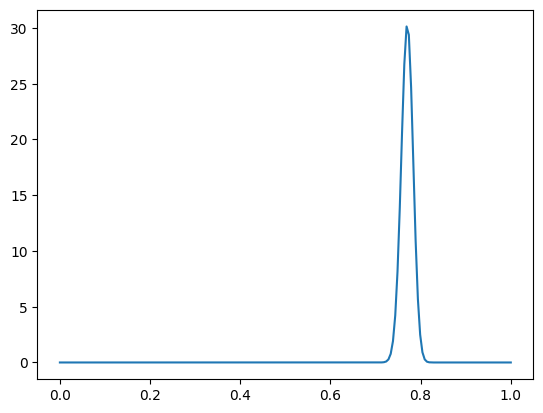

In [33]:
import matplotlib.pyplot as plt
prange = np.linspace(0,1,200)
plt.plot(prange,beta.pdf(prange,a,b))
plt.show()

We can now get the credible interval, say for $68\%$ probability. To do this we can use the ppf method exposed by scipy

In [34]:
prob = 0.68
low_p = 0.5*(1-0.68)
hig_p = 1-low_p
cr_int = beta.ppf([low_p,hig_p],a,b)
print(f"Credible interval [68%] for p_0 is: [{cr_int[0]},{cr_int[1]}]")
p_mle = N_success/N_shots
var_mle = p_mle*(1.-p_mle)/N_shots
print(f"Mean and error from MLE was: {p_mle} +- {np.sqrt(var_mle)}")
print(f"Confidence interval from MLE was: [{p_mle-np.sqrt(var_mle)},{p_mle+np.sqrt(var_mle)}]")

Credible interval [68%] for p_0 is: [0.7569200406843971,0.783044635592528]
Mean and error from MLE was: 0.7705078125 +- 0.013140820947426723
Confidence interval from MLE was: [0.7573669915525733,0.7836486334474267]


We can compare the posterior distribution with the Gaussian distribution with the maximum likelihood estimators. They are difficult to tell apart

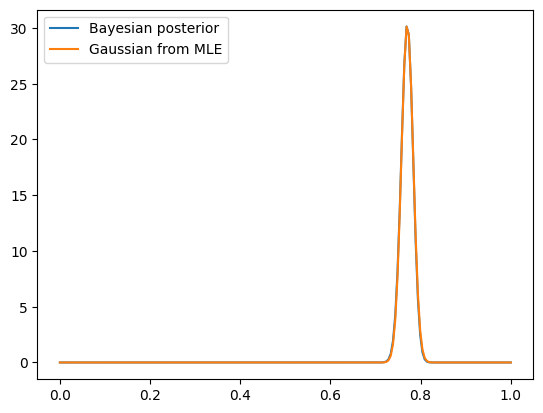

In [36]:
from scipy.stats import norm
prange = np.linspace(0,1,200)
plt.plot(prange,beta.pdf(prange,a,b),label="Bayesian posterior")
plt.plot(prange,norm.pdf(prange,loc=p_mle,scale=np.sqrt(var_mle)),label="Gaussian from MLE")
plt.legend()
plt.show()

This means that we indeed have enough shots for the Central Limit Theorem to be quantitatively correct. But this is not always the case.

For instance let's now try to change the angle $\theta$ and see what happens

In [37]:
theta=0.97*np.pi/2
# this is our target state
psi_theta = np.cos(theta)*state_01+np.sin(theta)*state_10
z0_ave = np.real(np.vdot(psi_theta,Z_0@psi_theta))
print(f"<Z_0>: {z0_ave}\t p_0: {(z0_ave+1)/2}")

<Z_0>: -0.9955619646030801	 p_0: 0.0022190176984599463


In [38]:
## we prepare the circuit first
circuitB = QuantumCircuit(2)
circuitB.ry(2*theta,0)
circuitB.x(1)
circuitB.cx(0, 1)
circuitB.measure_all()
## we transpile it
transpiledB = transpile(circuitB, backend=fake_lagrange_backend,optimization_level=2)
## we run it
## here we fix the random seed to a fixed random number for reproducibility
sample_jobB = sim_statevector.run(transpiledB,shots=1024,seed_simulator=17)
## we get the counts
zcountsB = sample_jobB.result().get_counts()
## we print them just 'cause
print(zcountsB)
## let's extract N_success and N_shots from it in the same way we did before
N_shotsB = sum([zcountsB[kk] for kk in zcountsB.keys()])
N_successB = 0
for kk in zcountsB.keys():
    num_qubits = len(kk)
    bit_values = np.array([int(kk[num_qubits-1-bit]) for bit in bits_for_Z_0])
    N_successB += zcountsB[kk]*np.all(bit_values==np.array([0]*len(bits_for_Z_0)))
print(f"For Z_0 we have: N_success = {N_successB} \t N_shots = {N_shotsB}" )

{'10': 4, '01': 1020}
For Z_0 we have: N_success = 4 	 N_shots = 1024


In [39]:
## update posterior parameters starting from uniform prior
a = 1 + N_successB
b = 1 + (N_shotsB - N_successB)
## get credible interval
prob = 0.68
low_p = 0.5*(1-0.68)
hig_p = 1-low_p
cr_int = beta.ppf([low_p,hig_p],a,b)
print(f"Credible interval [68%] for p_0 is: [{cr_int[0]},{cr_int[1]}]")
p_mle = N_successB/N_shotsB
var_mle = p_mle*(1.-p_mle)/N_shotsB
print(f"Mean and error from MLE was: {p_mle} +- {np.sqrt(var_mle)}")
print(f"Confidence interval from MLE was: [{p_mle-np.sqrt(var_mle)},{p_mle+np.sqrt(var_mle)}]")

Credible interval [68%] for p_0 is: [0.002780865675535048,0.006961967757119886]
Mean and error from MLE was: 0.00390625 +- 0.0019493065701503066
Confidence interval from MLE was: [0.001956943429849693,0.005855556570150307]


The Bayesian credible interval and the maximum likelihood confidence interval are now compatible bot much more different. This is reflected in the distributions

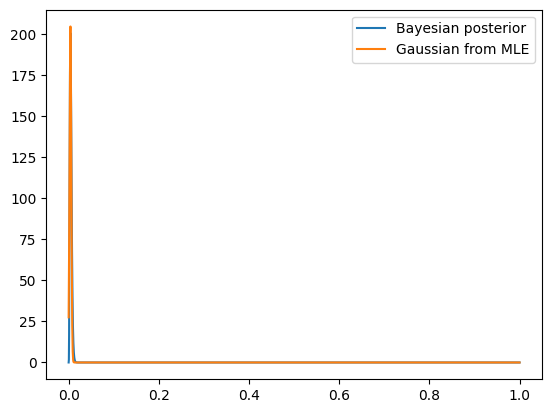

In [40]:
prange = np.linspace(0,1,2000)
plt.plot(prange,beta.pdf(prange,a,b),label="Bayesian posterior")
plt.plot(prange,norm.pdf(prange,loc=p_mle,scale=np.sqrt(var_mle)),label="Gaussian from MLE")
plt.legend()
plt.show()

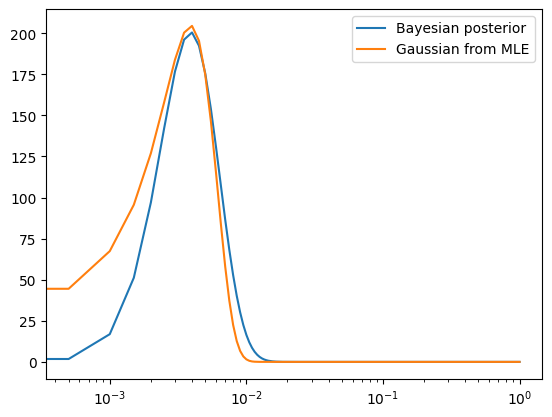

In [41]:
plt.semilogx(prange,beta.pdf(prange,a,b),label="Bayesian posterior")
plt.semilogx(prange,norm.pdf(prange,loc=p_mle,scale=np.sqrt(var_mle)),label="Gaussian from MLE")
plt.legend()
plt.show()

With enough shots the difference between the estimation protocols tends to become negligible. The main reasons to use a Bayesian approach, apart from philosophy, are

- we are interested in obtaining consitent credible/confidence intervals
- we are interested in measuring linear combinations of observables that might be dependent on each other
- we are interested in computing an reliable error estimate for expectation values of non-linear functions of measured probabilities

For the first point, imagine we want to produce credible/confidence intervals at various levels of failure probability pf. What we did so far was to only look for intervals corresponding to $pf=0.32$ (success $68\%$ of the time) but we might want to be more conservative. To do it we can do the following

In [42]:
num_pts = 100
pf_range=np.linspace(0.005,0.5,num_pts)

bayes_ci = np.zeros((num_pts,2))
mle_ci = np.zeros((num_pts,2))
for pf in range(num_pts):
    low_p = 0.5*pf_range[pf]
    high_p = 1-low_p
    ## get the beyesian first
    bayes_ci[pf,:] = beta.ppf([low_p,high_p],a,b)
    ## get the mle now
    zeta = norm.ppf(high_p)
    mle_ci[pf,0] = p_mle - zeta*np.sqrt(var_mle)
    mle_ci[pf,1] = p_mle + zeta*np.sqrt(var_mle)

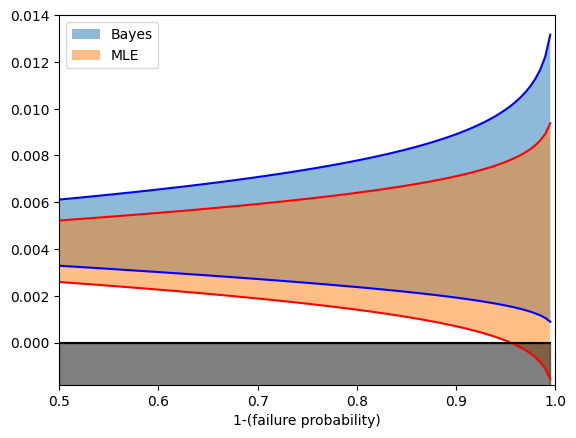

In [43]:
plt.plot(1-pf_range,bayes_ci[:,0],color='blue')
plt.plot(1-pf_range,bayes_ci[:,1],color='blue')
plt.fill_between(1-pf_range,bayes_ci[:,0],bayes_ci[:,1],alpha=0.5,label='Bayes')
plt.plot(1-pf_range,mle_ci[:,0],color='red')
plt.plot(1-pf_range,mle_ci[:,1],color='red')
plt.fill_between(1-pf_range,mle_ci[:,0],mle_ci[:,1],alpha=0.5,label='MLE')
plt.plot(1-pf_range,0.0*pf_range,color='black')
plt.fill_between(1-pf_range,-0.1*np.ones(len(pf_range)),0.0*pf_range,color='black',alpha=0.5)
plt.ylim([-0.0018,0.014])
plt.xlim([0.5,1.0])
plt.xlabel("1-(failure probability)")
plt.legend()
plt.show()

As we can see from the plot above, for small failure probabilities, the MLE confidence interval can start to include unphysical results (like negative probabilities) while the Bayesian credible interval is always meaningful. This comes from the fact that the latter does not need to be symmetric around the average like the former.

A simple case where we might want to estimate linear combinations of variables that are not independent is for instance the following expectation value

$$E(\alpha_1,\alpha_2,\alpha_3)=\alpha_1\langle Z_0\rangle+\alpha_1\langle Z_1\rangle + \alpha_2 \langle Z_0Z_1\rangle$$

On a system with two qubits, the expectation value of $\langle Z_0Z_1\rangle$ can be inferred from an estimate of $p_{00}$, the probability of measuring both qubits in the state $\rvert0\rangle$. On the other hand $\langle Z_0\rangle$ can be derived from the probability $p_0$ of observing just qubit $0$ in the $\rvert 0\rangle$ state while $\langle Z_0\rangle$ from $p_1$, the probability of observing qubit $1$ in the state $\rvert 0\rangle$. These last two are given by

$$p_0 = p_{00}+p_{10}\quad\quad p_1 = p_{00}+p_{01}$$

The probabilities for individual outcomes are however not indepent since, at least for a pure state, we need to have that

$$p_{00}+p_{01}+p_{10}+p_{11}=1$$

This is not a particular problem for point estimators of the expectation values but complicates a reliable estimation of the error.

For this case we can generalize the construction we have seen before, Beta prior with Binomial likelihood, with the corresponding multivariate form: Multinomial likelihood and Dirichlet prior. Also in this case the Dirichlet distribution is the conjugate prior of the Multinomial and we can therefore perform the Bayesian update in closed form. In this case the evaluation of a credible interval for $E(\alpha_1,\alpha_2,\alpha_3)$ might be best done by sampling the posterior distribution for the probabilities in order to generate samples the posterior probability for $E$. From these samples we can then estimate the credible interval directly from the samples.

An example for estimating the credible interval for a Beta posterior follows below

In [44]:
## define parameters alpha and beta for the posterior
a=120
b=300
## get credible interval
prob = 0.90
low_p = 0.5*(1-prob)
hig_p = 1-low_p
cr_int = beta.ppf([low_p,hig_p],a,b)
print(f"Exact 90% credible interval: [{cr_int[0]},{cr_int[1]}]")

Exact 90% credible interval: [0.25008310907737674,0.32250704909693284]


In [45]:
## produce num_samples samples of p_0 from its posterior
num_samples = 10000
p0_samples = beta.rvs(a,b,size=num_samples,random_state = 42) ## the last argument fixed random seed

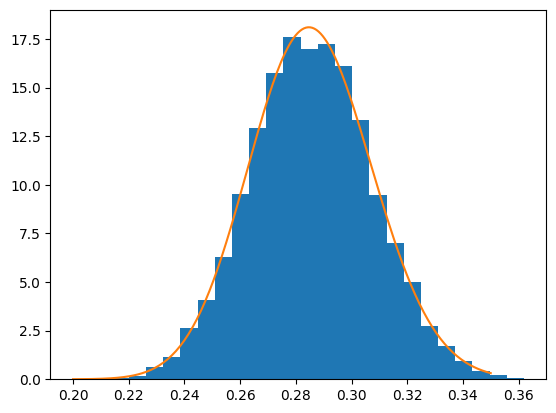

In [46]:
## compare empirical distribution with correct posterior
plt.hist(p0_samples, bins=25,density=True)
prange = np.linspace(0.2,0.35,200)
plt.plot(prange,beta.pdf(prange,a,b))

In [47]:
## extract 90% credible intervale from samples
### we first sort the samples
sorted_samples = np.sort(p0_samples)
### then extract the boundaries of the interval
prob = 0.90
low_p = 0.5*(1-prob)
hig_p = 1-low_p
cred_interval = [sorted_samples[int(low_p * num_samples)], sorted_samples[int(hig_p * num_samples)]]
### we now compare this estimate with the exact one
print(f"Exact 90% credible interval: [{cr_int[0]},{cr_int[1]}]")
print(f"Estimated 90% credible interval: [{cred_interval[0]},{cred_interval[1]}]")

Exact 90% credible interval: [0.25008310907737674,0.32250704909693284]
Estimated 90% credible interval: [0.25010844503943624,0.3222196170183337]


- **BONUS EXERCISE**: estimation of entanglement entropy

As an example of using Bayesian inference to estimate credible intervals for non-linear functions of observables we can consider the problem of estimating the **entanglement entropy** of qubit $0$ in the output $\rvert\Psi(\theta)\rangle$ of the circuit we used so far as a function of the angle $\theta$. If we call $\rho(theta)=\rvert\Psi(\theta)\rangle\langle\Psi(\theta)\lvert$ the density matrix corresponding to the final two qubit state, the reduced density matrix for qubit $0$ is obtained by tracing qubit $1$ away

$$\rho_0(\theta)=\text{Tr}_{1}\left[\rho(\theta)\right] =\sum_{q=0,1}\sum_{p=0,1}\rvert q\rangle\langle p\lvert\left(\langle 0q\lvert\rho(\theta)\rvert0p\rangle+\langle 1q\lvert\rho(\theta)\rvert1p\rangle\right)$$
    
The $2\times 2$ matrix $\rho_0(\theta)$ can be expressed explicitly in terms of Pauli matrices as follows

$$\rho_0(\theta) = \frac{1}{2}\left(\mathbb{1}+\langle X_0\rangle X +\langle Y_0\rangle Y +\langle Z_0\rangle Z \right)$$

As we saw at the beginning of the notebook, the expectation values of $X$ and $Y$ on the first qubit are always going to be zero and we therefore only need to consider a diagonal density matrix. This is particularly helpful when we want the entanglement entropy $S$ since this is defined as

$$S(\rho) = -\text{Tr}\left[\rho\log_2\left(\rho\right)\right]$$

In our case $\rho_0(\theta)$ is diagonal with eigenvalues given by

$$\lambda_+ = \frac{1+\langle Z_0\rangle}{2}\quad\quad\text{and}\quad\quad\lambda_- = \frac{1-\langle Z_0\rangle}{2}$$

and the entropy take then the closed form

$$S(\rho_0(\theta)) = -\frac{1+\langle Z_0\rangle}{2}\log_2\left(\frac{1+\langle Z_0\rangle}{2}\right)-\frac{1-\langle Z_0\rangle}{2}\log_2\left(\frac{1-\langle Z_0\rangle}{2}\right)$$

Or, alternatively, using the probability $p_0$ of measuring qubit $0$ in $\rvert0\rangle$ we get the simpler expression

$$S(\rho_0(\theta)) = -p_0\log_2\left(p_0\right)-\left(1-p_0\right)\log_2\left(1-p_0\right)$$

A point estimator for the entropy can then be found using

$$\widehat{S}(\rho_0(\theta)) = -\widehat{p_0}\log_2\left(\widehat{p_0}\right)-\left(1-\widehat{p_0}\right)\log_2\left(1-\widehat{p_0}\right)$$

Try to estimate the error on this estimator, in terms of a credible interval, on the entanglement entropy for various values of $\theta\in[0,\pi/2]$ by sampling $p_0$ from its posterior and generating the distribution for the entropy.

What would have happened if you used standard error propagation techniques in frequentist approach?